# Chapter 23: The Epidemiologist's Dilemma
Educational SIR scenarios, reporting delays and a simple nowcast. These simulated
curves are not medical forecasts. Transmission is specified, not estimated.

In [1]:
from pathlib import Path
import sys
project=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0,str(project/'companion/src'))
from forecasting_companion.common import *
from scipy.integrate import solve_ivp
rng=begin(23); days=np.arange(121); N=100000
def sir(beta):
    def rate(t,z):
        S,I,R=z; flow=beta*S*I/N; return [-flow,flow-.1*I,.1*I]
    return solve_ivp(rate,[0,120],[N-100,100,0],t_eval=days,rtol=1e-8,atol=1e-8).y

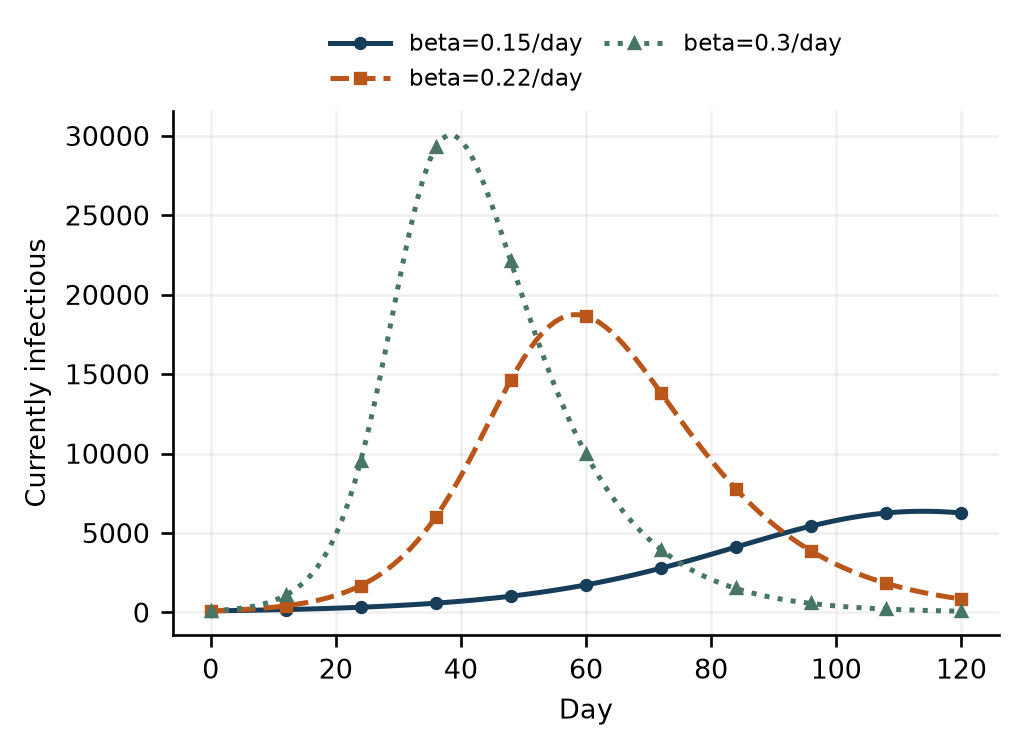

In [2]:
plt.figure()
for beta in [.15,.22,.3]:
    state=sir(beta); assert np.allclose(state.sum(axis=0),N); assert state.min()>-1e-6
    plt.plot(days,state[1],label=f'beta={beta}/day')
plt.xlabel('Day'); plt.ylabel('Currently infectious'); plt.legend(fontsize=7)
save(23,1,'Behavior scenarios produce different epidemic paths','Synthetic closed-population SIR trajectories with fixed removal rate 0.1/day. These are conditional scenarios, not estimated probabilities.','## Section Four: The Full Methodology')

## Recent event dates are incompletely reported
We generate a reporting triangle with a known delay distribution. The nowcast
divides reports by the fraction expected to be observed at the as-of date.

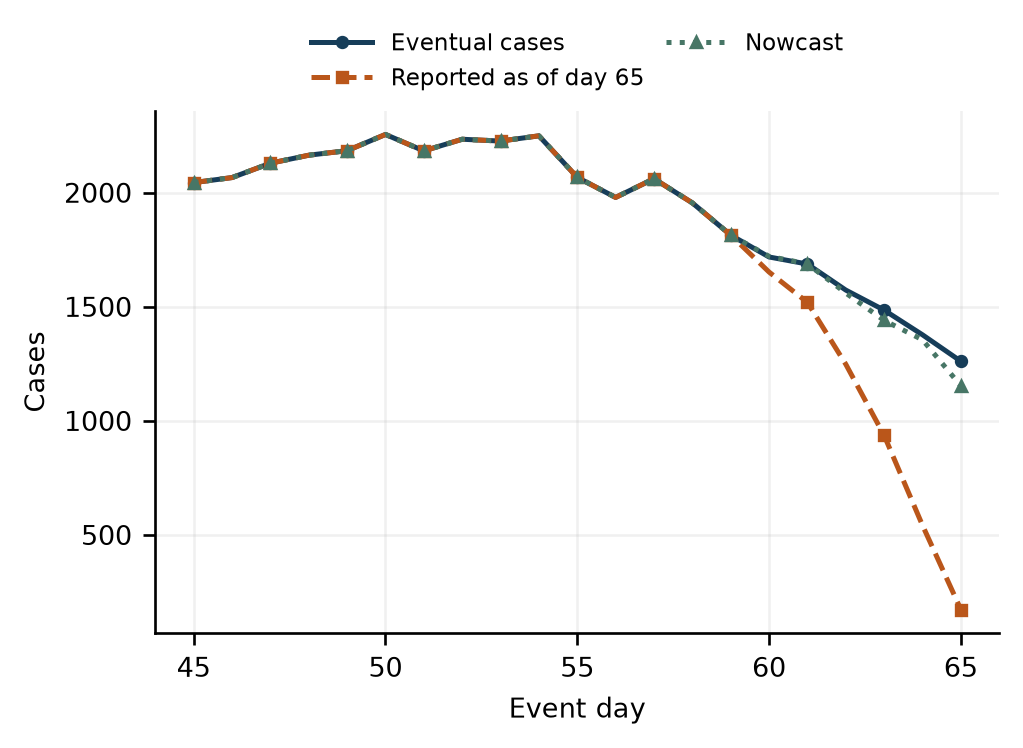

In [3]:
state=sir(.22); incidence=rng.poisson(np.maximum(0,.22*state[0]*state[1]/N))
delay_p=np.array([.15,.25,.25,.15,.1,.06,.04]); triangle=np.array([rng.multinomial(int(n),delay_p) for n in incidence])
asof=65; ages=asof-np.arange(asof+1); completeness=np.array([delay_p[:min(7,a+1)].sum() for a in ages]); reported=np.array([triangle[t,:min(7,asof-t+1)].sum() for t in range(asof+1)]); nowcast=reported/completeness
plt.figure(); plt.plot(np.arange(45,66),incidence[45:66],label='Eventual cases'); plt.plot(np.arange(45,66),reported[45:],label='Reported as of day 65'); plt.plot(np.arange(45,66),nowcast[45:],label='Nowcast'); plt.xticks(range(45,66,5)); plt.xlabel('Event day'); plt.ylabel('Cases'); plt.legend(fontsize=6)
save(23,2,'A falling report count may be a delay','Synthetic reporting triangle with a known seven-day delay distribution. The most recent dates have incomplete reports at the fixed as-of cutoff.','## Section Three: Nowcasting and the Real-Time Estimation Problem')

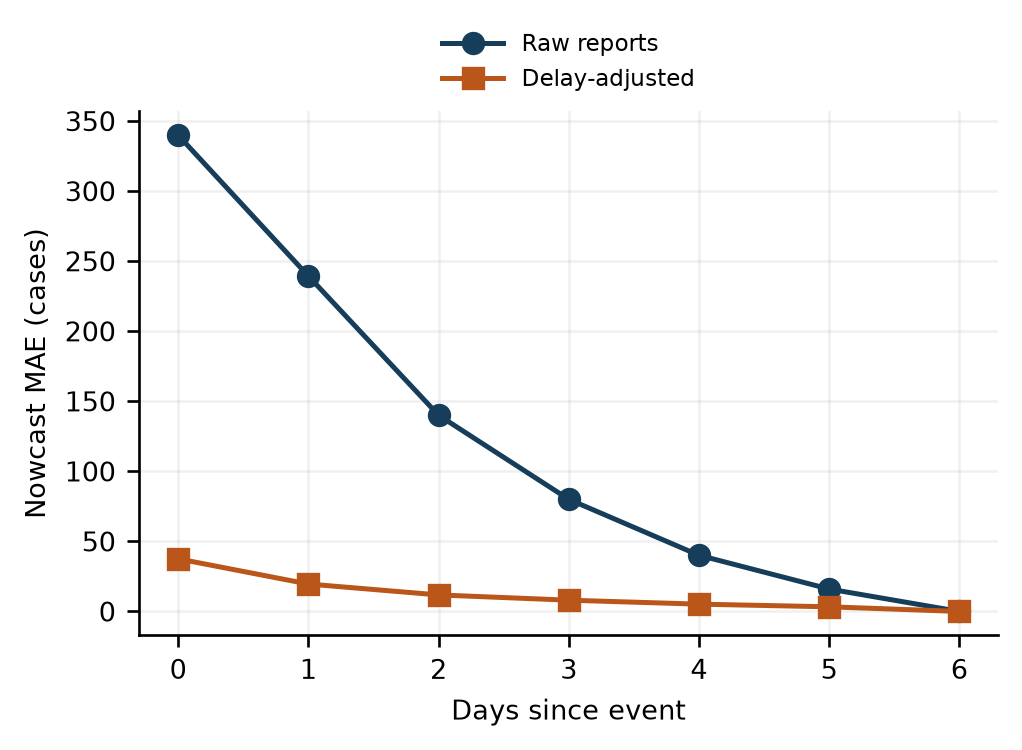

In [4]:
raw=[]; corrected=[]
for age in range(7):
    true=rng.poisson(400,2000); c=delay_p[:age+1].sum(); obs=rng.binomial(true,c)
    raw.append(np.mean(abs(obs-true))); corrected.append(np.mean(abs(obs/c-true)))
plt.figure(); plt.plot(range(7),raw,'o-',label='Raw reports'); plt.plot(range(7),corrected,'s-',label='Delay-adjusted'); plt.xlabel('Days since event'); plt.ylabel('Nowcast MAE (cases)'); plt.legend(fontsize=7)
save(23,3,'Adjustment helps but recent uncertainty remains','Repeated synthetic event counts under the known delay law. This evaluates nowcast error by reporting age, not future epidemic forecast accuracy.','## Section Five: The Universal Structure')

## Add an exposed compartment without losing people
SEIR separates infected-but-not-yet-infectious people from infectious people.
Sigma is the rate of becoming infectious, not automatically the inverse of
symptom incubation time. This example assumes a closed population and checks
both conservation and nonnegativity numerically.

In [5]:
def seir_rate(time, values):
    susceptible, exposed, infectious, recovered = values
    infections = .22*susceptible*infectious/N
    progression, removals = .25*exposed, .1*infectious
    return [-infections, infections-progression, progression-removals, removals]
seir = solve_ivp(seir_rate, [0,120], [N-150,50,100,0], t_eval=days,
                 rtol=1e-8, atol=1e-8).y
assert np.allclose(seir.sum(axis=0), N) and seir.min() > -1e-6
print('SEIR peak infectious:', float(seir[2].max()), 'on day', int(seir[2].argmax()))

SEIR peak infectious: 13300.973479913791 on day 92


## Score future forecasts separately from reporting-delay nowcasts
Observe noisy infectious counts from the synthetic SIR process. At each origin,
estimate transmission from earlier counts only, keeping the removal rate and
initial state fixed. Project the fitted dynamics and compare future counts with
persistence. This is an unusually favorable, correctly specified synthetic
experiment; real case reports do not directly measure infectious prevalence.

Origin 30 past-only fitted beta 0.21997742793306024
Origin 45 past-only fitted beta 0.2200159713542633
Origin 60 past-only fitted beta 0.22001539556480879
Origin 75 past-only fitted beta 0.22001691733205622


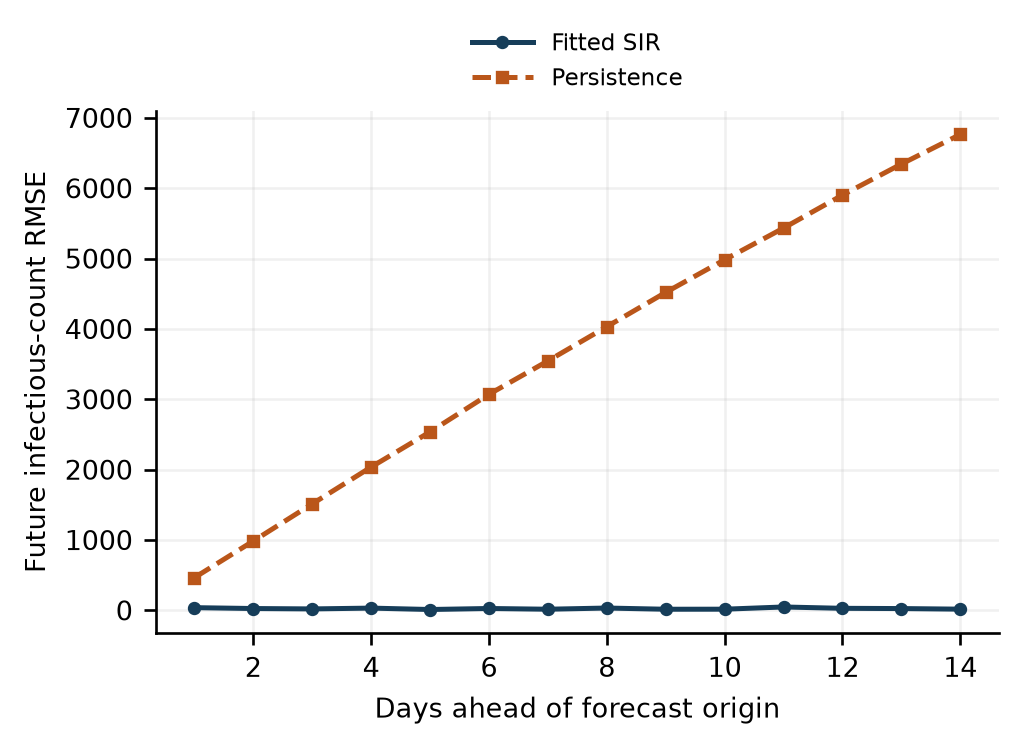

In [6]:
from scipy.optimize import least_squares
latent = sir(.22)[1]
measured = np.maximum(0, latent+rng.normal(0,25,len(days)))
horizons = np.arange(1,15)
future_errors = {'Fitted SIR': [], 'Persistence': []}
for origin in [30,45,60,75]:
    fitted_beta = least_squares(
        lambda parameter: (sir(float(parameter[0]))[1,:origin+1]-measured[:origin+1])/25,
        x0=[.2], bounds=([.1],[.4])).x[0]
    predicted = sir(float(fitted_beta))[1,origin+horizons]
    actual_future = measured[origin+horizons]
    future_errors['Fitted SIR'].append(predicted-actual_future)
    future_errors['Persistence'].append(np.repeat(measured[origin],len(horizons))-actual_future)
    print('Origin', origin, 'past-only fitted beta', float(fitted_beta))
plt.figure()
for name, errors in future_errors.items():
    errors = np.asarray(errors)
    assert errors.shape == (4,14) and np.isfinite(errors).all()
    plt.plot(horizons,np.sqrt(np.mean(errors**2,axis=0)),label=name)
plt.xlabel('Days ahead of forecast origin'); plt.ylabel('Future infectious-count RMSE'); plt.legend(fontsize=7)
save(23,4,'Score the epidemic forecast after its origin',
     'Four chronological origins on noisy synthetic infectious counts. Transmission is fitted using observations available at each origin; future SIR forecasts and persistence are scored on identical horizons. This is not reporting-delay nowcast error.',
     '## Section Five: The Universal Structure')

## Limits and exercise
Change the delay distribution halfway through the series. A stable historical
completeness factor can then fail. An SEIR exposed state represents a latent
infection-to-infectious period, not necessarily incubation to symptoms. Panel
regression, GAMs and hierarchical pooling are additional statistical approaches.

<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below come from the chapter skill: the mechanism, the arithmetic, how to adapt the lesson to your data, exercises with worked solutions, and the exact contract of the applied tool.

## Input contract and format example
A reporting triangle in long form: one row per (event date, report date) with the count reported on that date for that event date. Set `as_of` to the cutoff; later rows are discarded. The delay law is estimated from cohorts at least `mature_age` periods old (at least ten of them) unless `delay_prob` is supplied. Give `population` to fit the SEIR model; without it the mechanistic forecast is skipped and listed under `not_done`.

Minimal **format illustration**, not sufficient training data:

```csv
event_date,report_date,count
2020-01-01,2020-01-01,16
2020-01-01,2020-01-02,34
2020-01-02,2020-01-02,25
```

## Explain the mechanism

A nowcast estimates already-occurring but incompletely observed events. A future forecast predicts events not yet realized. Reporting processes and transmission dynamics therefore need distinct data and validation.

## Work through the arithmetic

If 40 cases have been reported for a date and its estimated completeness is .5, the simple nowcast is 80. With completeness .2 it becomes 200, showing sensitivity to delay assumptions. For SIR infection flow beta×S×I/N with beta=.3/day, S=900,I=100,N=1000, the flow is 27 infections/day.

## Adapt the lesson to reader data

Replace the generated reporting triangle with dated reports and a preserved cutoff. Keep delay probabilities separate from transmission parameters. Do not fit SIR prevalence directly to report-date incident counts without an explicit observation model.

For this chapter, settle these questions before fitting: Do counts represent event dates, report dates or prevalence? What was known as of the cutoff? Has reporting delay changed? What population and transmission assumptions are justified?

## Interpret the actual lesson outputs

The delay experiment knows its seven-day reporting law and evaluates nowcast error by reporting age. The separate fitted-SIR experiment has correctly specified dynamics and known removal/initial-state assumptions; it is unusually favorable. SEIR exposed-to-infectious rate is not automatically symptom-incubation rate.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `event_date,age,reported,completeness,nowcast,lower,upper`.
- `summary.json`: `delay_law,archived_evaluation,seir,as_of` plus method, interpretation, assumptions, not_done and status.

The tool builds the triangle at `as_of`, estimates the reporting-delay distribution from mature cohorts (truncated at `max_delay`) or takes the supplied `delay_prob`, nowcasts each incomplete cohort as reported count over completeness with negative-binomial 90 percent bounds, and evaluates the nowcast on archived mature cohorts by recomputing what it would have said at each younger age and scoring against the final count (an in-sample check, labelled as such). With `population` it fits an SEIR model (transmission rate, and the latent rate unless `sigma` is fixed) to incidence up to each of `origins` rolling origins and reports RMSE over `horizon` against persistence, with the implied basic reproduction number per origin. It does not model changes in testing, reporting holidays or interventions. The tool runs only when asked; the assistant decides, with the reader, whether the method fits before running it.

## Decide what the evidence supports

Small completeness makes recent nowcasts unstable. A stable historical delay law can fail after reporting changes. Case reports do not directly measure infectious prevalence. SIR fixed-rate scenarios are not probabilities over policy futures.

At zero completeness, report unidentifiable current totals rather than divide by zero. Without vintage reports, retrospective nowcast scoring may be impossible. Without defensible delay probabilities, provide observed reports and sensitivity scenarios.

The applied deliverable must make these items inspectable: `results.csv` columns: `event_date,age,reported,completeness,nowcast,lower,upper`; `summary.json` keys: `delay_law,archived_evaluation,seir,as_of` plus method, interpretation, assumptions, not_done and status. Report the archived-evaluation error by age beside the nowcast; the youngest cohorts carry the largest correction and the least evidence.

## Three exercises with worked solutions

### Exercise 1

Observed reports 30, completeness .75: nowcast?

**Worked solution.** 40 events, conditional on that completeness estimate.

### Exercise 2

A report arrives after the historical as-of date. May it enter that origin’s nowcast input?

**Worked solution.** No. It belongs only to later-vintage truth or a subsequent origin.

### Exercise 3

Completeness is zero for today. What is the simple adjusted count?

**Worked solution.** Undefined/unidentified from those reports. Report that status rather than zero or infinity as a usable forecast.

## Business-reader application

Use this request with the skill:

> Use chapter 23 to nowcast reporting_triangle.csv at the stated cutoff, audit delay stability and keep retrospective completion estimates separate from future transmission scenarios.

## Real-data boundary

The [data registry](../data/registry.json) and [data notes](../data/README.md) distinguish bundled observations from controlled fixtures. No matching observed-data application is claimed for this chapter. Supply the chapter-specific records and their provenance before treating the exercise as business evidence; an observed outcome table is not automatically a historical forecast journal or identified experiment.

Shared rules for data replacement, provenance, output folders and reading `status`: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).

## Apply this chapter to your own data

The two paths below are the only things to change: point `INPUT_PATH` at a file with the
columns in the input contract above and `CONFIG_PATH` at a copy of the shipped configuration
with your `source` and `units`. The call is the same tested function behind `run.py apply`.
The printed digest shows what ran, its status, the interpretation, the assumptions and the
`not_done` list; the full summary is saved beside the table. A validation error is a reason to
inspect the data, not to fill gaps with invented observations. Shared rules for provenance,
output folders and reading `status` are in the Complete Forecasting Skill's conventions reference.

In [7]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json, summarize, preview
import pandas as pd
import json, os
project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
INPUT_PATH = project_path / 'companion/data/examples/ch23.csv'      # replace with your file
CONFIG_PATH = project_path / 'companion/configs/ch23.json'            # replace with your configuration
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(23, workshop_input, workshop_config)
print(summarize(workshop_summary, workshop_table))
print()
print(preview(workshop_table))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', project_path / 'companion')) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch23-workshop-results.csv', index=False)
_ = (workshop_output/'ch23-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

Method: Reporting-triangle nowcast with estimated delay law and SEIR forecast
Status: passed

Interpretation: Delay law estimated from 41 cohorts aged 5+: [0.205, 0.311, 0.243, 0.143, 0.099, 0.0]. 5 event dates are still incomplete at the cutoff; their nowcasts carry 90% bounds from the completeness estimate. Archived nowcast MAE by age: {0: 14.372579015730988, 1: 8.290847348736891, 2: 5.047851707317072, 3: 2.9611280487804867, 4: 1.4557460927767907e-14}. SEIR mean RMSE 160 vs persistence 14.2 over 2 origins (R0 estimates [5.48, 1.68]). Nowcasting answers what is happening now; the SEIR block answers what may happen next; do not read one as proof of the other.

Assumptions:
  - Delay law stable across cohorts
  - Reports at the cutoff are complete for their lag
  - Eventual totals follow a negative binomial given the reported count

Evidence:
  delay_law: <4 entries>
  archived_evaluation: <3 entries>
  seir: <6 entries>
  as_of: 2020-02-15 00:00:00+00:00

Table: 46 rows, columns ['even